## Linear Programming

*Prepared by:*
**Jude Michael Teves**  
Faculty, Software Technology Department  
College of Computer Studies - De La Salle University

This notebook shows how to do linear programming in Python.

### Import libraries

We will be using the `pyomo` library for the succeeding cells. Theis will give us the functionalities we need to solve linear programming problems in Python. If this is not already installed in your environment, you may use the either of the following commands in your command line:

```conda install -c conda-forge pyomo``` or
```pip install Pyomo```

In [ ]:
!pip install Pyomo

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 48.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.3 MB/s eta 0:00:00


In [ ]:
from pyomo.environ import *

We also need to install the `glpk` library. I stands for "GNU Linear Programming Kit", which is a software package written in highly portable C for the solution of mixed integer linear programming and related problems.

We can use the following command to install it locally:
```conda install -c conda-forge glpk```

In google colab, see the cell below.

In [ ]:
!apt-get install -y -qq glpk-utils

For nonlinear optimization, we can use `ipopt`. To install, use the following command: ```conda install -c conda-forge ipopt```

### Pyomo model template

In [ ]:
model = ConcreteModel()

model.x = Var(domain=NonNegativeReals)
model.y = Var(domain=NonNegativeReals)

In [ ]:
model.profit = Objective(expr = 80*model.x + 20*model.y, sense=maximize)

In [ ]:
model.demand = Constraint(expr = model.x <= 60)
model.laborA = Constraint(expr = model.x + model.y <= 120)
model.laborB = Constraint(expr = 2*model.x + model.y <= 200)

In [ ]:
results = SolverFactory('glpk').solve(model)
results.write()
if results.solver.status == 'ok':
    model.pprint()

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 6000.0
  Upper bound: 6000.0
  Number of objectives: 1
  Number of constraints: 3
  Number of variables: 2
  Number of nonzeros: 5
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Termination condition: optimal
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: 0
      Number of created subproblems: 0
  Error rc: 0
  Time: 0.0135345458984375
# ----------------------------------------------------------
#   Solution Information
# ------------------------------------

In [ ]:
model.profit()

6000.0

In [ ]:
print('Profit = ', model.profit())

print('\nDecision Variables')
print('x = ', model.x())
print('y = ', model.y())

print('\nConstraints')
print('Demand  = ', model.demand())
print('Labor A = ', model.laborA())
print('Labor B = ', model.laborB())

Profit =  6000.0

Decision Variables
x =  60.0
y =  60.0

Constraints
Demand  =  60.0
Labor A =  120.0
Labor B =  180.0


## Production Model with Linear Constraints

The following is heavily based from <a href="https://jckantor.github.io/ND-Pyomo-Cookbook/README.html">Pyomo's cookbook</a>.

### Product X

Suppose you are thinking about starting up a business to produce Product X. You have determined there is a market for X of up to 40 units per week at a price of USD 270 each. The production of each unit requires USD 100 of raw materials, 1 hour of type A labor, and 2 hours of type B labor. You have an unlimited amount of raw material available to you, but only 80 hours per week of labor A at a cost of USD 50/hour, and 100 hours per week of labor B at a cost of USD 40 per hour. Ignoring all other expenses, what is the maximum weekly profit?

To get started on this problem, we sketch a flow diagram illustrating the flow of raw materials and labor through the production plant.  

<!-- <img src="../images/quotes-to-scrape-console.png"> -->

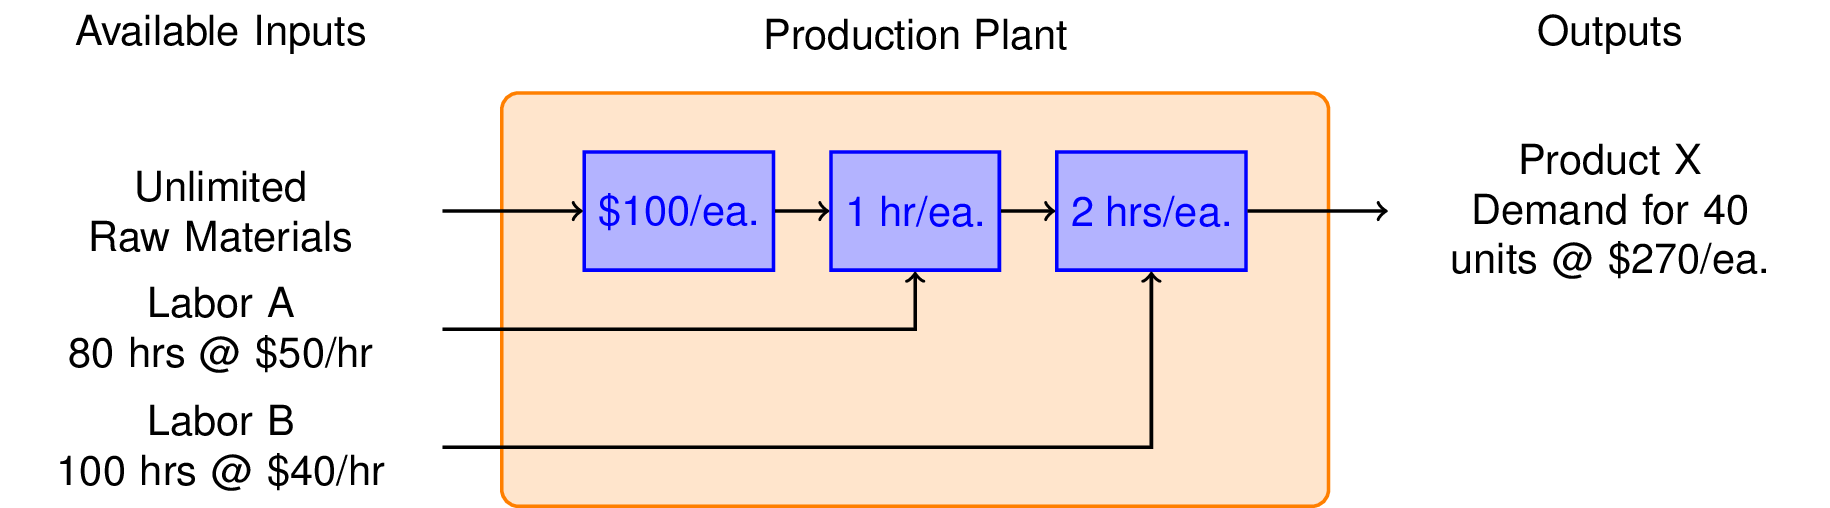



The essential decision we need to make is how many units or Product X to produce each week. That's our decision variable which we denote as
$x$. The weekly revenues are then

$$Revenue = \$270x$$

The costs include the value of the raw materials and each form of labor. If we produce x units a week, then the total cost is  

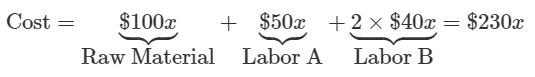

We see immediately that the gross profit is just

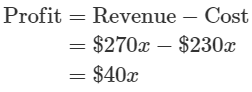

which means there is a profit earned on each unit of X produced, so let’s produce as many as possible.

There are three constraints that limit how many units can be produced. There is market demand for no more than 40 units per week. Producing $x=40$
 units per week will require 40 hours per week of Labor A, and 80 hours per week of Labor B. Checking those constraints we see that we have enough labor of each type, so the maximum profit will be

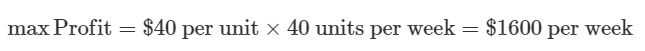

What we conclude is that market demand is the ‘most constraining constraint.’ Once we’ve made that deduction, the rest is a straightforward problem that can be solved by inspection.

In [ ]:
model = ConcreteModel()

# declare decision variables
model.x = Var(domain=NonNegativeReals)

# declare objective
model.profit = Objective(
    expr = 40*model.x,
    sense = maximize)

# declare constraints
model.demand = Constraint(expr = model.x <= 40)
model.laborA = Constraint(expr = model.x <= 80)
model.laborB = Constraint(expr = 2*model.x <= 100)

# solve
SolverFactory('glpk').solve(model).write()

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 1600.0
  Upper bound: 1600.0
  Number of objectives: 1
  Number of constraints: 3
  Number of variables: 1
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Termination condition: optimal
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: 0
      Number of created subproblems: 0
  Error rc: 0
  Time: 0.00758051872253418
# ----------------------------------------------------------
#   Solution Information
# -----------------------------------

In [ ]:
model.profit.display()
model.x.display()
print(f"Profit = {model.profit()} per week")
print(f"X = {model.x()} units per week")

profit : Size=1, Index=None, Active=True
    Key  : Active : Value
    None :   True : 1600.0
x : Size=1, Index=None
    Key  : Lower : Value : Upper : Fixed : Stale : Domain
    None :     0 :  40.0 :  None : False : False : NonNegativeReals
Profit = 1600.0 per week
X = 40.0 units per week


### Product Y

Your marketing department has developed plans for a new product called Y. The product sells at a price of USD 210/each, and they expect that you can sell all that you can make. It’s also cheaper to make, requiring only USD 90 in raw materials, 1 hour of Labor type A at USD 50 per hour, and 1 hour of Labor B at USD 40 per hour. What is the potential weekly profit?  

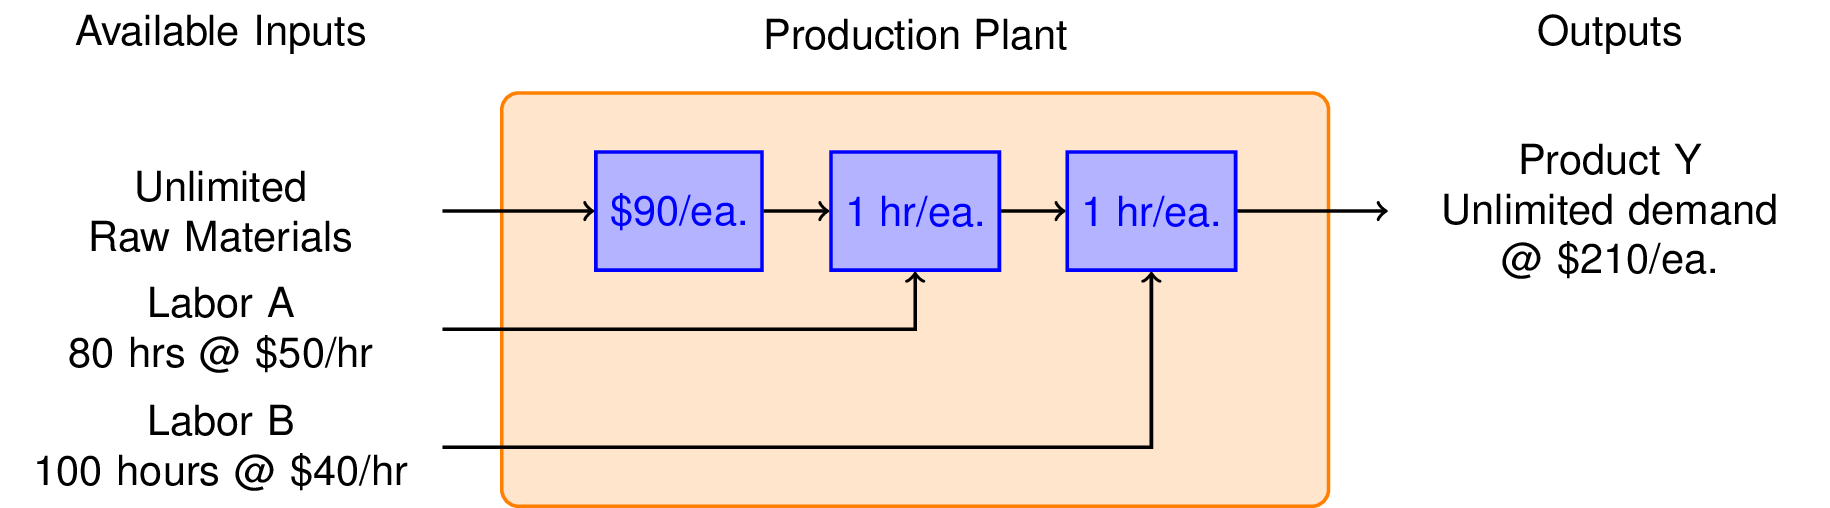

In [ ]:
model = ConcreteModel()

# declare decision variables
model.y = Var(domain=NonNegativeReals)

# declare objective
model.profit = Objective(
    expr = 30*model.y,
    sense = maximize)

# declare constraints
model.laborA = Constraint(expr = model.y <= 80)
model.laborB = Constraint(expr = model.y <= 100)

# solve
SolverFactory('glpk').solve(model).write()

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 2400.0
  Upper bound: 2400.0
  Number of objectives: 1
  Number of constraints: 2
  Number of variables: 1
  Number of nonzeros: 2
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Termination condition: optimal
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: 0
      Number of created subproblems: 0
  Error rc: 0
  Time: 0.004915952682495117
# ----------------------------------------------------------
#   Solution Information
# ----------------------------------

In [ ]:
print(f"Profit = {model.profit()}")
print(f"Units of Y = {model.y()}")

Profit = 2400.0
Units of Y = 80.0


Compared to product X, we can manufacture and sell up 80 units per week for a total profit of $2,400. This is very welcome news.

### Mixed Product Strategy

So far we have learned that we can make $$1,600 per week by manufacturing product X, and $2,400 per week manufacturing product Y. Is it possible to do even better?

To answer this question, we consider the possibilty of manufacturing both products in the same plant. The marketing department assures us that product Y will not affect the sales of product X. So the same constraints hold as before, but now we have two decision variables, $x$ and $y$.  

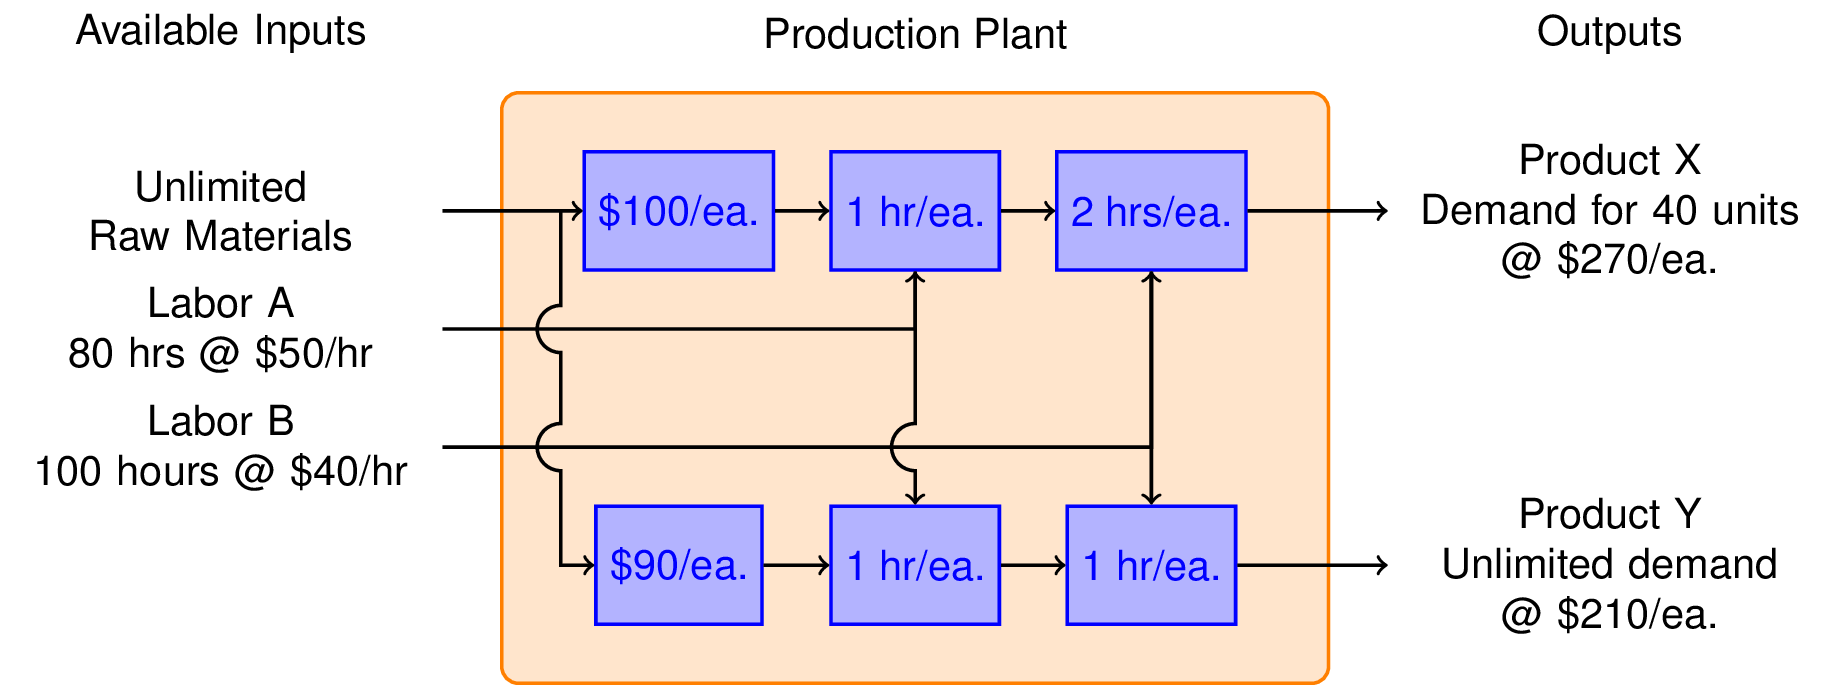

In [ ]:
model = ConcreteModel()

# declare decision variables
model.x = Var(domain=NonNegativeReals)
model.y = Var(domain=NonNegativeReals)

# declare objective
model.profit = Objective(
    expr = 40*model.x + 30*model.y,
    sense = maximize)

# declare constraints
model.demand = Constraint(expr = model.x <= 40)
model.laborA = Constraint(expr = model.x + model.y <= 80)
model.laborB = Constraint(expr = 2*model.x + model.y <= 100)

# solve
SolverFactory('glpk').solve(model).write()

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 2600.0
  Upper bound: 2600.0
  Number of objectives: 1
  Number of constraints: 3
  Number of variables: 2
  Number of nonzeros: 5
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Termination condition: optimal
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: 0
      Number of created subproblems: 0
  Error rc: 0
  Time: 0.005925655364990234
# ----------------------------------------------------------
#   Solution Information
# ----------------------------------

In [ ]:
# display solution
print(f"Profit = {model.profit()}")
print(f"Units of X = {model.x()}")
print(f"Units of Y = {model.y()}")

Profit = 2600.0
Units of X = 20.0
Units of Y = 60.0


#### Visualizing the constraints

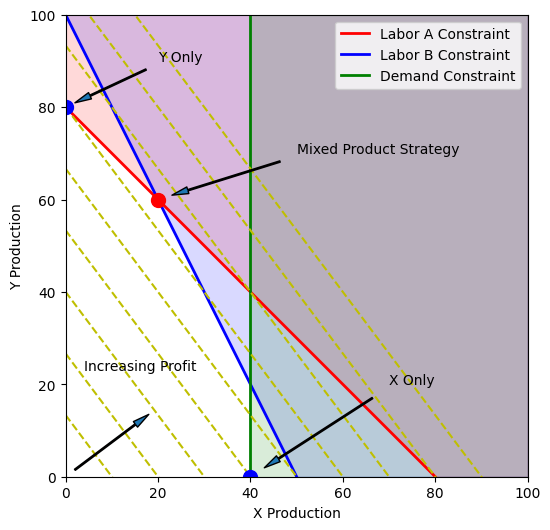

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.set_aspect('equal')
ax.axis([0, 100, 0, 100])
ax.set_xlabel('X Production')
ax.set_ylabel('Y Production')

# Labor A constraint
x = np.array([0, 80])
ax.plot(x, 80 - x, 'r', lw=2)

# Labor B constraint
x = np.array([0, 50])
ax.plot(x, 100 - 2*x, 'b', lw=2)

# Demand constraint
ax.plot([40, 40], [0, 100], 'g', lw=2)

ax.legend(['Labor A Constraint', 'Labor B Constraint', 'Demand Constraint'])
ax.fill_between([0, 80, 100], [80, 0,0 ], [100, 100, 100], color='r', alpha=0.15)
ax.fill_between([0, 50, 100], [100, 0, 0], [100, 100, 100], color='b', alpha=0.15)
ax.fill_between([40, 100], [0, 0], [100, 100], color='g', alpha=0.15)

# Contours of constant profit
x = np.array([0, 100])
for p in np.linspace(0, 3600, 10):
    y = (p - 40*x)/30
    ax.plot(x, y, 'y--')

arrowprops = dict(shrink=.1, width=1, headwidth=5)

# Optimum
ax.plot(20, 60, 'r.', ms=20)
ax.annotate('Mixed Product Strategy', xy=(20, 60), xytext=(50, 70), arrowprops=arrowprops)

ax.plot(0, 80, 'b.', ms=20)
ax.annotate('Y Only', xy=(0, 80), xytext=(20, 90), arrowprops=arrowprops)

ax.plot(40, 0, 'b.', ms=20)
ax.annotate('X Only', xy=(40, 0), xytext=(70, 20), arrowprops=arrowprops)

ax.text(4, 23, 'Increasing Profit')
ax.annotate('', xy=(20, 15), xytext=(0,0), arrowprops=arrowprops)

# fname = 'LPprog01.png'
# fname = os.path.join('figures', fname) if os.path.exists('figures') else fname
# plt.savefig(fname, bbox_inches='tight')
plt.show()

## Mixed Blending Problem

A brewery receives an order for 100 gallons of 4% ABV (alchohol by volume) beer. The brewery has on hand beer A that is 4.5% ABV that cost USD 0.32 per gallon to make, and beer B that is 3.7% ABV and cost USD 0.25 per gallon. Water could also be used as a blending agent at a cost of USD 0.05 per gallon. Find the minimum cost blend that meets the customer requirements.

We turn the data into `dict` format.

In [ ]:
vol = 100
abv = 0.040

data = {
    'A': {'abv': 0.045, 'cost': 0.32},
    'B': {'abv': 0.037, 'cost': 0.25},
    'W': {'abv': 0.000, 'cost': 0.05},
}

In [ ]:
# sum(model.x[c]*data[c]['cost'] for c in C)
[model.x[c]*data[c]['cost'] for c in C]

In [ ]:
C = data.keys()
model = ConcreteModel()
model.x = Var(C, domain=NonNegativeReals)
model.cost = Objective(expr = sum(model.x[c]*data[c]['cost'] for c in C))
model.vol = Constraint(expr = vol == sum(model.x[c] for c in C))
model.abv = Constraint(expr = 0 == sum(model.x[c]*(data[c]['abv'] - abv) for c in C))

solver = SolverFactory('glpk')
solver.solve(model)

print('Optimal Blend')
for c in data.keys():
    print('  ', c, ':', model.x[c](), 'gallons')
print()
print('Volume = ', model.vol(), 'gallons')
print('Cost = $', model.cost())

Optimal Blend
   A : 37.5 gallons
   B : 62.5 gallons
   W : 0.0 gallons

Volume =  100.0 gallons
Cost = $ 27.625


## References

1. https://jckantor.github.io/ND-Pyomo-Cookbook/README.html

## End
<sup>made by **Jude Michael Teves**</sup> <br>
<sup>for comments, corrections, suggestions, please email:</sup><sup> <href>judemichaelteves@gmail.com</href> or <href>jude.teves@dlsu.edu.ph</href></sup><br>